In [ ]:
import pandas as pd

data = {
    "Student_ID": [1,2,3,4,5,6,7,8,9,10],
    "Gender": ["Female","Male","Female","Male","Female","Male","Female","Male","Female","Male"],
    "Attendance": [85,70,90,60,95,80,75,50,88,65],
    "Study_Hours": [4,2,6,1,7,3,5,1,6,2],
    "Internal_Marks": [18,15,20,10,22,16,17,8,21,14],
    "External_Marks": [65,55,75,40,85,60,68,35,78,50],
    "Assignment_Score": [20,18,22,15,24,19,21,12,23,16]
}

df = pd.DataFrame(data)

df.to_csv("student_data.csv", index=False)

print("Dataset Created Successfully ✅")
df.head()

Dataset Created Successfully ✅


,Student_ID,Gender,Attendance,Study_Hours,Internal_Marks,External_Marks,Assignment_Score
0,1,Female,85,4,18,65,20
1,2,Male,70,2,15,55,18
2,3,Female,90,6,20,75,22
3,4,Male,60,1,10,40,15
4,5,Female,95,7,22,85,24


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
df = pd.read_csv("student_data.csv")

print("First 5 Rows:")
df.head()

First 5 Rows:


,Student_ID,Gender,Attendance,Study_Hours,Internal_Marks,External_Marks,Assignment_Score
0,1,Female,85,4,18,65,20
1,2,Male,70,2,15,55,18
2,3,Female,90,6,20,75,22
3,4,Male,60,1,10,40,15
4,5,Female,95,7,22,85,24


In [ ]:
df.isnull().sum()

,0
Student_ID,0
Gender,0
Attendance,0
Study_Hours,0
Internal_Marks,0
External_Marks,0
Assignment_Score,0


In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

In [ ]:
df['Total_Marks'] = df['Internal_Marks'] + df['External_Marks'] + df['Assignment_Score']

In [ ]:
def performance_category(marks):
    if marks >= 100:
        return "Excellent"
    elif marks >= 80:
        return "Good"
    elif marks >= 60:
        return "Average"
    else:
        return "Poor"

df['Performance'] = df['Total_Marks'].apply(performance_category)

df.head()

,Student_ID,Gender,Attendance,Study_Hours,Internal_Marks,External_Marks,Assignment_Score,Total_Marks,Performance
0,1,0,85,4,18,65,20,103,Excellent
1,2,1,70,2,15,55,18,88,Good
2,3,0,90,6,20,75,22,117,Excellent
3,4,1,60,1,10,40,15,65,Average
4,5,0,95,7,22,85,24,131,Excellent


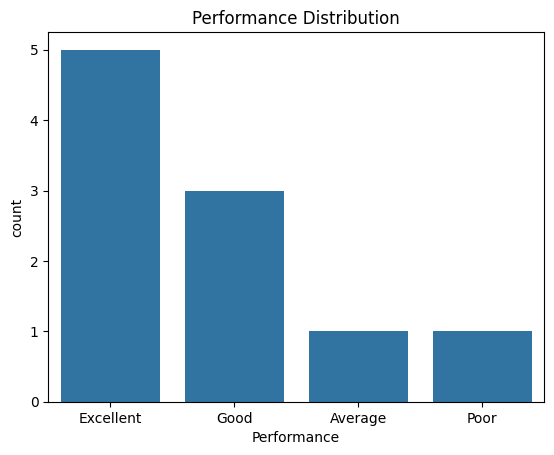

In [ ]:
sns.countplot(x='Performance', data=df)
plt.title("Performance Distribution")
plt.show()

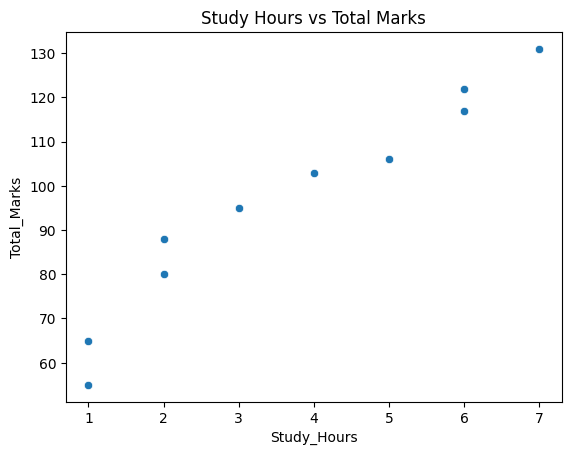

In [ ]:
sns.scatterplot(x='Study_Hours', y='Total_Marks', data=df)
plt.title("Study Hours vs Total Marks")
plt.show()

sns.scatterplot(x='Attendance', y='Total_Marks', data=df)
plt.title("Attendance vs Total Marks")
plt.show()

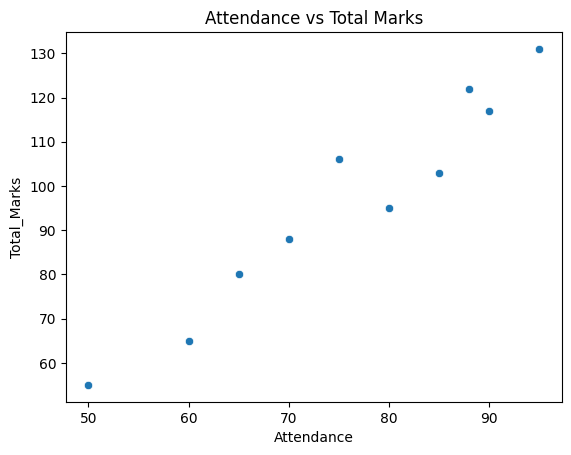

In [ ]:
sns.scatterplot(x='Attendance', y='Total_Marks', data=df)
plt.title("Attendance vs Total Marks")
plt.show()

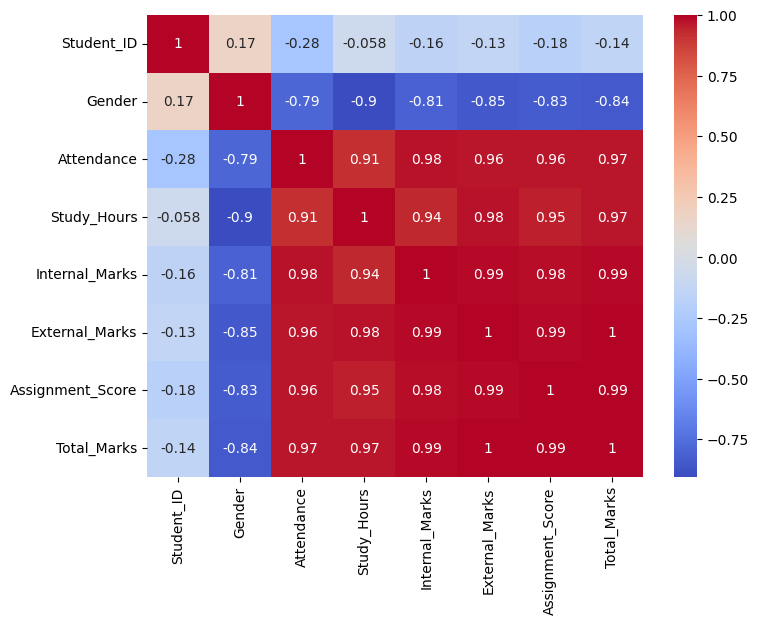

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df.select_dtypes(include=['number']).corr(), annot=True, cmap='coolwarm')
plt.show()

In [31]:
X = df[['Gender','Attendance','Study_Hours','Internal_Marks','External_Marks','Assignment_Score']]
y = df['Performance']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Data Split Successfully ✅")

Data Split Successfully ✅


In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("Model Trained Successfully ✅")

Model Trained Successfully ✅


In [ ]:
y_pred = model.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

   Excellent       1.00      1.00      1.00         1
        Good       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2


Confusion Matrix:
 [[1 0]
 [0 1]]


In [ ]:
def predict_student():
    print("Enter Student Details")

    gender = int(input("Gender (0 = Female, 1 = Male): "))
    attendance = float(input("Attendance (%): "))
    study_hours = float(input("Study Hours: "))
    internal = float(input("Internal Marks: "))
    external = float(input("External Marks: "))
    assignment = float(input("Assignment Score: "))

    data = [[gender, attendance, study_hours, internal, external, assignment]]

    prediction = model.predict(data)

    print("\nPredicted Performance:", prediction[0])

predict_student()

Enter Student Details
Gender (0 = Female, 1 = Male): 0
Attendance (%): 33
Study Hours: 77
Internal Marks: 100
External Marks: 60
Assignment Score: 45

Predicted Performance: Excellent


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


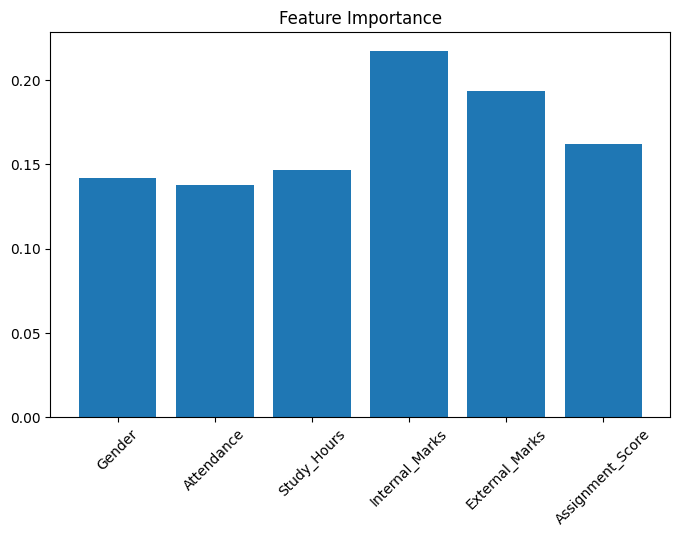

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

importance = model.feature_importances_
features = X.columns

plt.figure(figsize=(8,5))
plt.bar(features, importance)
plt.title("Feature Importance")
plt.xticks(rotation=45)
plt.show()

In [ ]:
import joblib

joblib.dump(model, "student_performance_model.pkl")

print("Model Saved Successfully ✅")

Model Saved Successfully ✅


In [ ]:
import sqlite3
import pandas as pd

# Create database
conn = sqlite3.connect("student_database.db")

# Create table
conn.execute("""
CREATE TABLE students (
    Student_ID INTEGER,
    Gender TEXT,
    Attendance INTEGER,
    Study_Hours INTEGER,
    Internal_Marks INTEGER,
    External_Marks INTEGER,
    Assignment_Score INTEGER
)
""")

print("Database and Table Created Successfully ✅")

Database and Table Created Successfully ✅


In [32]:
import sqlite3

In [33]:
# Create database file
conn = sqlite3.connect("student_database.db")

# Store dataframe into SQL table
df.to_sql("students", conn, if_exists="replace", index=False)

print("Data successfully stored in SQL database ✅")

Data successfully stored in SQL database ✅


In [34]:
query = "SELECT * FROM students"
df_sql = pd.read_sql(query, conn)

df_sql.head()

,Student_ID,Gender,Attendance,Study_Hours,Internal_Marks,External_Marks,Assignment_Score,Total_Marks,Performance
0,1,0,85,4,18,65,20,103,Excellent
1,2,1,70,2,15,55,18,88,Good
2,3,0,90,6,20,75,22,117,Excellent
3,4,1,60,1,10,40,15,65,Average
4,5,0,95,7,22,85,24,131,Excellent
